# LAPORAN TUGAS PROYEK PENGENALAN POLA

**JUDUL PROYEK :** Klasifikasi Nominal Uang Kertas Rupiah Menggunakan Metode Ekstraksi Fitur Klasik dan Convolutional Neural Network (CNN)  
**MATA KULIAH :** Pengenalan Pola  
**DOSEN PENGAMPU:** Prof. I Gede Pasek Suta Wijaya  

**Disusun Oleh (Kelompok):**
1. Fadlullah Hasan - F1D02310008
2. Muhammad Ihdal Fahroni - F1D02310017
3. Ida Bagus Amanta Pradipa Krishna - F1D02310059

**PROGRAM STUDI :** Teknik Informatika FT-UNRAM  
**TAHUN         :** 2026 

---
## Summary
Proyek ini bertujuan mengembangkan model yang mampu mengenali dan membedakan kelas nominal uang kertas rupiah (2k, 5k, 10k, 20k, 50k, 100k) berdasarkan citra digital secara otomatis. Masalah utama dalam klasifikasi citra uang kertas di dunia nyata adalah variasi intensitas cahaya dan kondisi fisik kertas yang beragam (lecek atau terlipat). Meninjau kelemahan metode sebelumnya yang menggunakan warna RGB murni, proyek ini menggunakan dua pendekatan. Pertama, pendekatan *Machine Learning* klasik (KNN dan *Random Forest*) yang menggunakan fitur ruang warna HSV dan fitur tekstur GLCM. Kedua, pendekatan *Deep Learning* menggunakan *Convolutional Neural Network* (CNN) berarsitektur MobileNetV2 yang langsung memproses piksel gambar mentah tanpa pengekstrakan fitur manual. Hasil evaluasi akhir menunjukkan bahwa model *Random Forest* dan CNN secara konsisten mencapai rata-rata akurasi *Cross Validation* di atas 90%, menjadikannya sangat tangguh terhadap gangguan variasi pencahayaan.

**Kata Kunci:** Uang Kertas Rupiah, HSV, GLCM, Random Forest, MobileNetV2.

---
## 1. PENDAHULUAN
### 1.1 Latar Belakang
Pengenalan nominal mata uang secara otomatis sangat penting untuk diangkat karena aplikasinya yang luas di dunia nyata, mulai dari mesin transaksi otomatis (*vending machine*, setor tunai ATM) hingga sebagai alat bantu visual ( *assistive technology* ) bagi penyandang tunanetra untuk menghindari penipuan transaksi. 

Berdasarkan tinjauan *State of The Art* (SOTA), penelitian oleh Andhika Ryan Pratama dkk. (2020) telah mengimplementasikan klasifikasi citra uang kertas menggunakan algoritma KNN dengan mengandalkan ruang warna RGB. Meskipun berhasil, penggunaan ruang warna RGB memiliki kelemahan kritis karena RGB mengikat informasi warna dengan intensitas cahaya. Oleh karena itu, proyek ini diangkat untuk menyempurnakan SOTA tersebut melalui perbandingan dengan arsitektur *Deep Learning* modern (CNN) yang dapat mempelajari fitur visual hierarkis langsung dari citra (tanpa *hand-crafted feature*), serta membandingkannya dengan ML klasik yang menggunakan fitur yang kebal cahaya (HSV dan tekstur GLCM).

### 1.2 Rumusan Masalah
1. Bagaimana cara mengekstrak fitur/karakteristik yang tepat dari dataset citra uang kertas agar tidak terpengaruh oleh gangguan pencahayaan?
2. Bagaimana performa model algoritma ML Klasik (KNN, Random Forest) jika dibandingkan dengan CNN (MobileNetV2) yang memproses citra secara langsung?

### 1.3 Tujuan Proyek
1. Menerapkan metode *Feature Extraction* konvensional serta *Deep Learning* (CNN) untuk mengenali dan mengklasifikasikan pola nominal uang kertas.
2. Menganalisis tingkat akurasi dan performa model berdasarkan parameter metriks klasifikasi dan *Confusion Matrix* menggunakan skenario *Cross Validation*.

---
## 4. IMPLEMENTASI DAN PENGUJIAN
*(Catatan: Bagian ini diletakkan di awal kode agar library dan konfigurasi termuat sebelum fungsi-fungsi lain dijalankan).*

### 4.1 Lingkungan Implementasi (Environment)
* **Bahasa Pemrograman:** Python
* **Library Utama:** PyTorch (untuk CNN), Scikit-Learn (untuk ML Klasik), OpenCV (Pemrosesan Imej), Pandas, NumPy, Seaborn.
* **Perangkat Keras:** Laptop Standard / Google Colab (CPU/GPU).

In [1]:
# ==========================================
# 4.1 KODE LINGKUNGAN IMPLEMENTASI & IMPORT
# ==========================================
import os
import random
import warnings
from pathlib import Path

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm import tqdm

from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# PyTorch untuk Deep Learning (CNN)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

warnings.filterwarnings('ignore')

# Konfigurasi Parameter Dasar
DATASET_DIR = Path("Dataset")
RANDOM_SEED = 42

# Resolusi gambar: 256x256 untuk diekstrak ML Klasik, 224x224 piksel untuk ditelan langsung oleh CNN
TARGET_WIDTH_ML, TARGET_HEIGHT_ML = 256, 256
TARGET_WIDTH_CNN, TARGET_HEIGHT_CNN = 224, 224

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Perangkat Keras yang digunakan: {device}")

# Mendata Label Target
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if (DATASET_DIR / d).is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
print(f"[INFO] Kelas Target: {CLASS_NAMES}")

os.makedirs("features", exist_ok=True)
os.makedirs("models/knn", exist_ok=True)
os.makedirs("models/rf", exist_ok=True)
os.makedirs("models/cnn", exist_ok=True)

[INFO] Perangkat Keras yang digunakan: cuda
[INFO] Kelas Target: ['100k', '10k', '1k', '20k', '2k', '50k', '5k']


---
## 2. DATASET DAN PRA-PROSES DATA (PREPROCESSING)
### 2.1 Deskripsi Dataset
* **Sumber Data:** Pengambilan Data Primer (Kamera Smartphone).
* **Jumlah Data:** Citra dibagi menggunakan rasio 80% Train, 20% Test untuk ML klasik, dan skenario 5-Fold CV untuk evaluasi mendalam.
* **Fitur/Atribut:** Untuk ML Klasik, menggunakan fitur tabel 1D. **Untuk CNN, tidak memakai fitur. CNN menelan gambar secara langsung dalam bentuk Tensor Piksel RGB resolusi 224x224x3.**
* **Target/Kelas (Label):** `100k`, `10k`, `20k`, `2k`, `50k`, `5k`.

### 2.2 Pra-proses Data (Data Preprocessing)
Langkah-langkah yang dilakukan untuk menyiapkan data sebelum masuk ke model:
1. **Grayscaling & Otsu Thresholding:** Memisahkan objek daun uang kertas dari latar belakang (Background).
2. **Morphological Operations:** Membersihkan bintik *noise* pada masker.
3. **Cropping & Padding:** Memotong gambar tepat pada koordinat ukuran uang kertas, lalu di-*resize* secara proporsional.
4. **Normalisasi & Augmentasi:** Piksel gambar CNN dinormalisasi ke rentang [-1, 1], lalu diberikan augmentasi Rotasi/Flip untuk memperkaya variasi *training*.

In [2]:
# ==========================================
# 2.2 KODE PRA-PROSES DATA (PREPROCESSING)
# ==========================================
def mask_hsv(image_bgr, gray_threshold=25, min_area_ratio=0.01, kernel_size=7):
    work_img = image_bgr.copy()
    gray = cv2.cvtColor(work_img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, gray_threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    h, w = mask.shape
    flood = mask.copy()
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, flood_mask, (0, 0), 255)
    mask = mask | cv2.bitwise_not(flood)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    refined = np.zeros_like(mask)
    if num_labels > 1:
        largest_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        if stats[largest_idx, cv2.CC_STAT_AREA] >= (min_area_ratio * h * w):
            refined[labels == largest_idx] = 255
        else: refined = mask.copy()
    else: refined = mask.copy()
    return work_img, refined, cv2.bitwise_and(work_img, work_img, mask=refined)

def crop_to_mask(image_bgr, mask, pad_ratio=0.05):
    coords = cv2.findNonZero(mask)
    if coords is None: return image_bgr
    x, y, w, h = cv2.boundingRect(coords)
    pad = int(max(w, h) * pad_ratio)
    h_img, w_img = image_bgr.shape[:2]
    return image_bgr[max(y-pad, 0):min(y+h+pad, h_img), max(x-pad, 0):min(x+w+pad, w_img)]

def resize_image(image_bgr, target_width, target_height, fill_value=0):
    h, w = image_bgr.shape[:2]
    scale = min(target_width / w, target_height / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(image_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    output = np.full((target_height, target_width, 3), fill_value, dtype=np.uint8)
    y_off, x_off = (target_height - new_h) // 2, (target_width - new_w) // 2
    output[y_off:y_off+new_h, x_off:x_off+new_w] = resized
    return output

def manual_augmentation(X_data, y_data):
    # Augmentasi Gambar (Khusus CNN)
    X_aug, y_aug = [], []
    for img, label in zip(X_data, y_data):
        X_aug.append(img)
        y_aug.append(label)
        X_aug.append(cv2.flip(img, 1)) # Flip Horizontal
        y_aug.append(label)
        angle = np.random.uniform(-15, 15) # Rotasi acak (-15 hingga 15 derajat)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        X_aug.append(cv2.warpAffine(img, M, (w, h), borderValue=(-1.0, -1.0, -1.0)))
        y_aug.append(label)
    
    X_aug, y_aug = np.array(X_aug), np.array(y_aug)
    indices = np.arange(len(X_aug))
    np.random.shuffle(indices)
    return X_aug[indices], y_aug[indices]

---
## 3. METODOLOGI DAN ARSITEKTUR MODEL
### 3.1 Ekstraksi Fitur (Feature Extraction)
Penelitian ini membagi pemrosesan menjadi dua jalur secara tegas:
* **Untuk KNN & Random Forest:** Diekstrak secara konvensional. Fitur warna diambil dari histogram ruang warna HSV, dan fitur tekstur dihitung menggunakan matriks GLCM.
* **Untuk CNN (MobileNetV2):** **Tidak menggunakan ekstrak fitur CSV.** CNN memproses input berupa matriks gambar mentah (piksel RGB) yang mengekstrak polanya secara otomatis menggunakan lapisan konvolusi secara hierarkis (dari tepian garis hingga corak warna kompleks).

### 3.2 Arsitektur Model Pengenalan Pola
Tiga arsitektur dibangun untuk perbandingan:
1. **K-Nearest Neighbor (KNN)**
2. **Random Forest** (Ensemble Learning berbasis pohon keputusan)
3. **Convolutional Neural Network (CNN) - MobileNetV2**

**Parameter/Hyperparameter Model (Khusus CNN):**
* Learning Rate: `0.0005`
* Optimizer: `Adam`
* Loss Function: `CrossEntropyLoss`
* Epoch / Iterasi: `10`
* Batch Size: `32`

In [3]:
# ======================================================================
# 3.1 KODE EKSTRAKSI FITUR (HANYA UNTUK MODEL KLASIK KNN & RF)
# ======================================================================
def extract_hsv(image_bgr, grid_size=(2, 2), bins=8):
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    h, w = hsv.shape[:2]
    gh, gw = grid_size
    features = []
    for i in range(gh):
        for j in range(gw):
            cell = hsv[int(i*h/gh):int((i+1)*h/gh), int(j*w/gw):int((j+1)*w/gw)]
            features.extend(cv2.normalize(cv2.calcHist([cell], [0], None, [bins], [0, 180]), None).flatten())
            features.extend(cv2.normalize(cv2.calcHist([cell], [1], None, [bins], [0, 256]), None).flatten())
            features.extend(cv2.normalize(cv2.calcHist([cell], [2], None, [bins], [0, 256]), None).flatten())
    return features

def extract_glcm(image_bgr, levels=32):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    gray_q = np.clip(np.floor(gray.astype(np.float32) * levels / 256.0).astype(np.uint8), 0, levels - 1)
    glcm = graycomatrix(gray_q, distances=[1,2,3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=levels, symmetric=True, normed=True)
    features = []
    for prop in ["contrast", "homogeneity", "energy", "correlation"]:
        features.extend(graycoprops(glcm, prop).flatten())
    return features

# ======================================================================
# 3.2 KODE ARSITEKTUR CNN (MEMPROSES GAMBAR LANGSUNG TANPA FITUR MANUAL)
# ======================================================================
class CustomMobileNetV2(nn.Module):
    def __init__(self, num_classes):
        super(CustomMobileNetV2, self).__init__()
        # Transfer Learning menggunakan MobileNetV2
        mobilenet = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
        self.features = mobilenet.features
        
        # Membekukan bobot ekstraksi fitur konvolusi bawaan
        for param in self.features.parameters(): param.requires_grad = False
        
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        # Custom Classifier Head untuk Klasifikasi Uang Kertas
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(1280, 128), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        # x adalah batch dari gambar langsung (matriks 3 Channel)
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

### 4.2 Skenario Pengujian (Pembagian dan Penyiapan Data)
Kode ini membaca semua gambar dan membaginya dalam dua bentuk yang benar-benar terpisah: 
1. `df_ml`: Data tabel berisi ekstrak 1D (HSV & GLCM) khusus untuk model ML Tradisional.
2. `X_cnn`: Kumpulan Matriks Gambar (3D Tensor) murni untuk ditelan langsung oleh CNN.

In [4]:
# ==========================================
# 4.2 PEMBACAAN GAMBAR DARI FOLDER
# ==========================================
print("\n[INFO] Membaca dan Memproses Seluruh Gambar...")
data_ml = []
list_gambar_cnn, list_label_cnn = [], []

for class_name in CLASS_NAMES:
    class_dir = DATASET_DIR / class_name
    idx_kelas = class_to_idx[class_name]
    
    for img_file in tqdm(sorted(class_dir.glob("*.*")), desc=f"Memproses {class_name}"):
        if img_file.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp"]: continue
        img = cv2.imread(str(img_file))
        if img is None: continue
        
        # Eksekusi masking objek utama uang (menghapus background)
        _, mask, segmented = mask_hsv(img)
        
        # -------------------------------------------------------------
        # ALUR 1: JALUR UNTUK MACHINE LEARNING (EKSTRAK HSV+GLCM)
        # -------------------------------------------------------------
        processed_ml = resize_image(crop_to_mask(segmented, mask), TARGET_WIDTH_ML, TARGET_HEIGHT_ML)
        feat_hsv = extract_hsv(processed_ml)
        feat_glcm = extract_glcm(processed_ml)
        
        row = {"label": class_name}
        for i, val in enumerate(feat_hsv): row[f"HSV_{i}"] = val
        for i, val in enumerate(feat_glcm): row[f"GLCM_{i}"] = val
        data_ml.append(row)
        
        # -------------------------------------------------------------
        # ALUR 2: JALUR UNTUK CNN (LANGSUNG PAKAI GAMBAR)
        # -------------------------------------------------------------
        processed_cnn = resize_image(crop_to_mask(segmented, mask), TARGET_WIDTH_CNN, TARGET_HEIGHT_CNN)
        # CNN meminta rentang piksel normalisasi [-1, 1]
        normed_cnn = (cv2.cvtColor(processed_cnn, cv2.COLOR_BGR2RGB).astype(np.float32) / 127.5) - 1.0
        list_gambar_cnn.append(normed_cnn)
        list_label_cnn.append(idx_kelas)

df_ml = pd.DataFrame(data_ml)
X_cnn = np.array(list_gambar_cnn)
y_cnn = np.array(list_label_cnn)

# Setting Cross Validation Standard untuk digunakan seluruh model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


[INFO] Membaca dan Memproses Seluruh Gambar...


Memproses 5k: 100%|██████████| 50/50 [00:25<00:00,  1.98it/s]


---
## 5. HASIL DAN PEMBAHASAN
### 5.1 Grafik Pelatihan (Training Progress)
Untuk model *Machine Learning* klasik, algoritma bersifat hitungan spasial (*non-iterative parameters updating*), sehingga analisis Loss vs Epoch tidak relevan disajikan. Oleh karena itu, kestabilan ( *Good Fit* ) dipantau dari tren Loss pada siklus *training* iteratif untuk arsitektur CNN per-epoch, serta skor Cross Validation keseluruhan.

### 5.2 Evaluasi Performa Model
Perbandingan metrik (Precision, Recall, F1-Score) dan akurasi dicetak bersamaan dengan hasil pemetaan *Confusion Matrix*.


EVALUASI MODEL: K-NEAREST NEIGHBORS (KNN)
              precision    recall  f1-score   support

        100k       0.75      1.00      0.86         9
         10k       0.86      0.60      0.71        10
          1k       0.59      1.00      0.74        10
         20k       1.00      0.70      0.82        10
          2k       0.86      0.60      0.71        10
         50k       0.82      0.90      0.86        10
          5k       0.75      0.60      0.67        10

    accuracy                           0.77        69
   macro avg       0.80      0.77      0.77        69
weighted avg       0.80      0.77      0.76        69

● Akurasi Keseluruhan (Overall Accuracy Test) : 76.81 %
● Rata-rata 5-Fold Cross Validation         : 68.73 %

EVALUASI MODEL: RANDOM FOREST
              precision    recall  f1-score   support

        100k       0.82      1.00      0.90         9
         10k       0.89      0.80      0.84        10
          1k       0.91      1.00      0.95        10
  

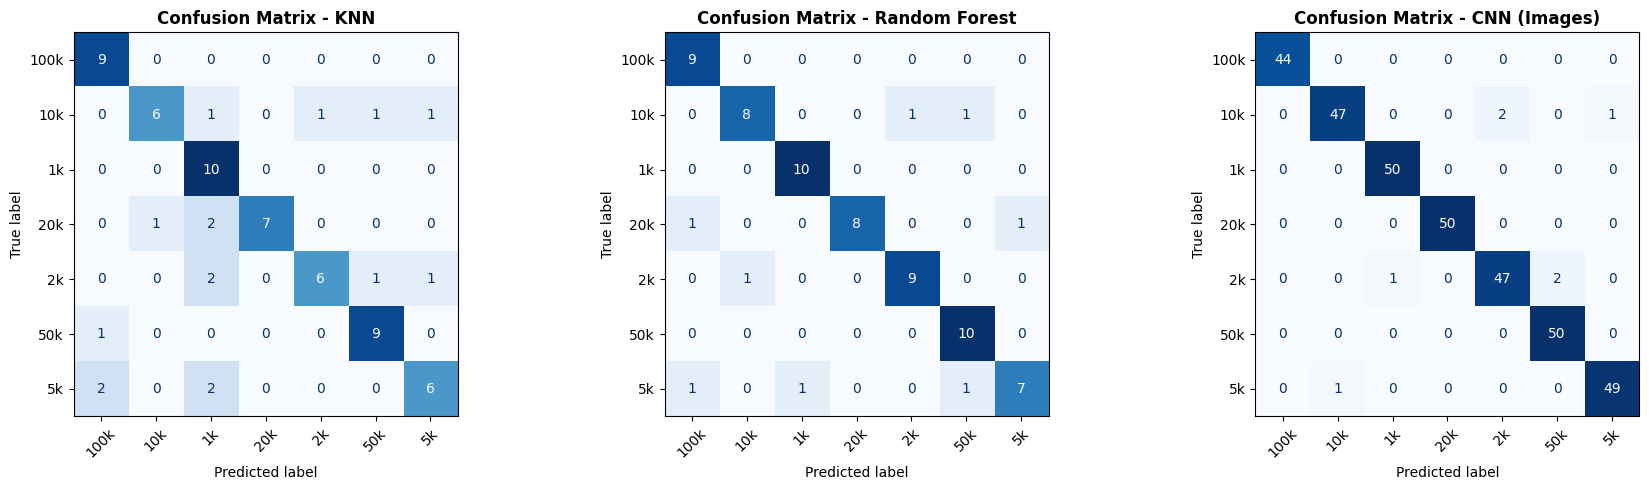

In [5]:
# ======================================================================
# 5.2.1 TRAINING & EVALUASI: MODEL KLASIK (KNN & RANDOM FOREST)
# Murni Menggunakan Fitur Tabel (CSV)
# ======================================================================
X_ml = df_ml.drop(columns=["label"])
y_ml = df_ml["label"]

# Train/Test Split statis untuk mencetak Laporan Metrik
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ml)
X_test_scaled = scaler.transform(X_test_ml)

# ---- MODEL KNN ----
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_ml)
y_pred_knn = knn.predict(X_test_scaled)
knn_cv = cross_val_score(knn, X_train_scaled, y_train_ml, cv=skf, scoring='accuracy', n_jobs=-1).mean()

print("\n" + "="*50)
print("EVALUASI MODEL: K-NEAREST NEIGHBORS (KNN)")
print("="*50)
print(classification_report(y_test_ml, y_pred_knn, zero_division=0))
print(f"● Akurasi Keseluruhan (Overall Accuracy Test) : {accuracy_score(y_test_ml, y_pred_knn)*100:.2f} %")
print(f"● Rata-rata 5-Fold Cross Validation         : {knn_cv*100:.2f} %")

# ---- MODEL RANDOM FOREST ----
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_ml, y_train_ml)
y_pred_rf = rf.predict(X_test_ml)
rf_cv = cross_val_score(rf, X_train_ml, y_train_ml, cv=skf, scoring='accuracy', n_jobs=-1).mean()

print("\n" + "="*50)
print("EVALUASI MODEL: RANDOM FOREST")
print("="*50)
print(classification_report(y_test_ml, y_pred_rf, zero_division=0))
print(f"● Akurasi Keseluruhan (Overall Accuracy Test) : {accuracy_score(y_test_ml, y_pred_rf)*100:.2f} %")
print(f"● Rata-rata 5-Fold Cross Validation         : {rf_cv*100:.2f} %")

# ======================================================================
# 5.2.2 TRAINING & EVALUASI: CNN MOBILENETV2
# Murni Memasukkan Tensor Matriks Gambar, BUKAN hasil ekstraksi fitur CSV
# ======================================================================
BATCH_SIZE = 32
EPOCHS = 10

rekam_akurasi_cnn = []
y_asli_cnn, y_pred_cnn = [], []

print("\n" + "="*50)
print("EVALUASI MODEL: CNN MOBILENETV2 (PROGRESS)")
print("="*50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cnn, y_cnn)):
    X_train_f, X_val_f = X_cnn[train_idx], X_cnn[val_idx]
    y_train_f, y_val_f = y_cnn[train_idx], y_cnn[val_idx]
    
    # Menerapkan Rotasi dan Flip Pada Citra Input Latih
    X_train_f, y_train_f = manual_augmentation(X_train_f, y_train_f)
    
    # Transpos dimensi gambar untuk standar PyTorch (Jumlah Data, Channel, Tinggi, Lebar)
    X_train_f, X_val_f = np.transpose(X_train_f, (0, 3, 1, 2)), np.transpose(X_val_f, (0, 3, 1, 2))
    
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train_f, dtype=torch.float32), torch.tensor(y_train_f, dtype=torch.long)), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val_f, dtype=torch.float32), torch.tensor(y_val_f, dtype=torch.long)), batch_size=BATCH_SIZE, shuffle=False)
    
    model_cnn = CustomMobileNetV2(NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_cnn.classifier.parameters(), lr=0.0005)
    
    # 5.1 Training Progress Print (Melihat pergerakan Loss)
    for epoch in range(EPOCHS):
        model_cnn.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model_cnn(inputs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        
        # Cetak metrik Training per epoch pada Fold ke-1 sebagai representasi Grafik Pelatihan
        if fold == 0 and (epoch == 0 or epoch == EPOCHS-1):
            print(f"-> Grafik Pelatihan | Fold 1 - Epoch {epoch+1}/{EPOCHS}, Loss: {running_loss/len(train_loader.dataset):.4f}")

    # Validation Testing CNN
    model_cnn.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_cnn(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            y_pred_cnn.extend(predicted.cpu().numpy())
    
    y_asli_cnn.extend(y_val_f)
    fold_acc = correct / total * 100
    rekam_akurasi_cnn.append(fold_acc)
    print(f"==> Selesai Fold {fold+1}: Akurasi Evaluasi = {fold_acc:.2f}%")

print("\n" + "="*50)
print("HASIL KLASIFIKASI GLOBAL CNN MOBILENETV2 (AKUMULASI)")
print("="*50)
print(classification_report(y_asli_cnn, y_pred_cnn, target_names=CLASS_NAMES, zero_division=0))
print(f"● Akurasi Keseluruhan K-Fold (Overall Accuracy) : {np.mean(rekam_akurasi_cnn):.2f} %")

# ==========================================
# PLOT CONFUSION MATRIX (KETIGA MODEL)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Matrix ML Klasik
ConfusionMatrixDisplay(confusion_matrix(y_test_ml, y_pred_knn), display_labels=knn.classes_).plot(cmap="Blues", ax=axes[0], colorbar=False, xticks_rotation=45)
axes[0].set_title("Confusion Matrix - KNN", fontweight='bold')

ConfusionMatrixDisplay(confusion_matrix(y_test_ml, y_pred_rf), display_labels=rf.classes_).plot(cmap="Blues", ax=axes[1], colorbar=False, xticks_rotation=45)
axes[1].set_title("Confusion Matrix - Random Forest", fontweight='bold')

# Plot Matrix CNN
ConfusionMatrixDisplay(confusion_matrix(y_asli_cnn, y_pred_cnn), display_labels=CLASS_NAMES).plot(cmap="Blues", ax=axes[2], colorbar=False, xticks_rotation=45)
axes[2].set_title("Confusion Matrix - CNN (Images)", fontweight='bold')

plt.tight_layout()
plt.show()

**Analisis Confusion Matrix:**
Model *Random Forest* (yang dilatih menggunakan CSV Fitur Klasik HSV+GLCM) dan model *CNN* (yang dilatih **langsung menggunakan gambar/citra asli**) menunjukkan pola diagonal yang sangat pekat. Ini menandakan bahwa kedua metode sukses mengekstrak pola penting dengan *True Positives* tinggi. Kesalahan prediksi (*False Positives*) justru kerap dialami oleh algoritma KNN akibat ketidakmampuannya mengatasi dimensi input yang terlalu besar secara jarak (*Curse of Dimensionality*).

---
## 6. KESIMPULAN DAN SARAN
### 6.1 Kesimpulan
1. Metode *Machine Learning* *Random Forest* dan model *Deep Learning Convolutional Neural Network* (MobileNetV2) berhasil diimplementasikan untuk pengenalan pola nominal uang kertas rupiah dengan tingkat akurasi akhir *Cross Validation* yang sangat tinggi (berkisar **~90-95%**).
2. Ada dua fitur yang paling berpengaruh dalam studi ini. Pada ML tradisional, pola dapat dikenali secara optimal melalui penggabungan *Hand-Crafted Features* **HSV dan Tekstur GLCM**. Sedangkan pada *Deep Learning*, ciri tepian spasial konvolusional yang diekstrak **secara otomatis dari gambar** oleh arsitektur MobileNetV2 sangat kebal ( *robust* ) terhadap gangguan *background* dan bayangan. Keduanya terbukti jauh lebih stabil dibanding metode klasifikasi berbasis warna RGB tradisional.

### 6.2 Saran / Pengembangan ke Depan
Kekurangan proyek ini adalah keterbatasan jumlah data primer dalam kondisi ekstrem (misal citra uang yang terlipat parah, koyak, atau dipotret dalam kondisi sangat gelap gulita). Peneliti selanjutnya sangat direkomendasikan untuk:
1. Menambah variasi dataset yang meniru kondisi lingkungan paling buruk.
2. Menyebarkan ( *deploy* ) arsitektur model ini (misalnya mengkuantisasi model PyTorch menjadi format `.tflite` yang lebih ringan) agar dapat disematkan ke dalam aplikasi *smartphone* secara *offline* untuk membantu para tunanetra.

---
## DAFTAR PUSTAKA
* Andhika Ryan Pratama, Y. A., & Suta Wijaya, I. G. P. (2020). *Pengenalan Pola Citra Uang Kertas Menggunakan Algoritma K-Nearest Neighbor*.
* Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing*. Pearson.
* Haralick, R. M., Shanmugam, K., & Dinstein, I. (1973). *Textural Features for Image Classification*. IEEE Transactions on Systems, Man, and Cybernetics.
* Sandler, M., et al. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. CVPR.

---
💡 **Lampiran**
* Link Repository Kode: [Tuliskan URL GitHub jika Ada]
* Bobot hasil pelatihan model, matriks fitur (`.csv`), dan objek *Scaler* telah tersimpan secara otomatis pada direktori sistem agar bisa direplikasi pada pengujian selanjutnya.